# Modelo ESTATICO 

In [ ]:
# %% =========================
# 1. CARGA Y LIMPIEZA
# =========================

import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix


df_unido = pd.read_csv("csv/online_retail_unificado.csv")
df = df_unido.copy()
df_sin_duplicados = df.drop_duplicates()
df = df_sin_duplicados.copy()

Registros limpios: 779425
Clientes únicos: 5878
Rango fechas: 2009-12-01 07:45:00 → 2011-12-09 12:50:00
Facturas únicas: 36969
Cutoff date: 2011-06-01 15:41:48
Fin ventana target: 2011-08-30 15:41:48
Filas dataset estático: 4937

Distribución target:
target
0    3325
1    1612
Name: count, dtype: int64
target
0    0.673486
1    0.326514
Name: proportion, dtype: float64

Train clientes: 3456
Test clientes: 1481
Split date: 2011-04-06 13:41:00

ROC-AUC: 0.8119071416809316

Matriz de confusión:
[[125 454]
 [ 39 863]]

Classification report:
              precision    recall  f1-score   support

           0       0.76      0.22      0.34       579
           1       0.66      0.96      0.78       902

    accuracy                           0.67      1481
   macro avg       0.71      0.59      0.56      1481
weighted avg       0.70      0.67      0.61      1481

Precision base: 0.609
Precision top 20%: 0.953
Lift: 1.56

Top 25 coeficientes por magnitud:
num__cantidad_total                 

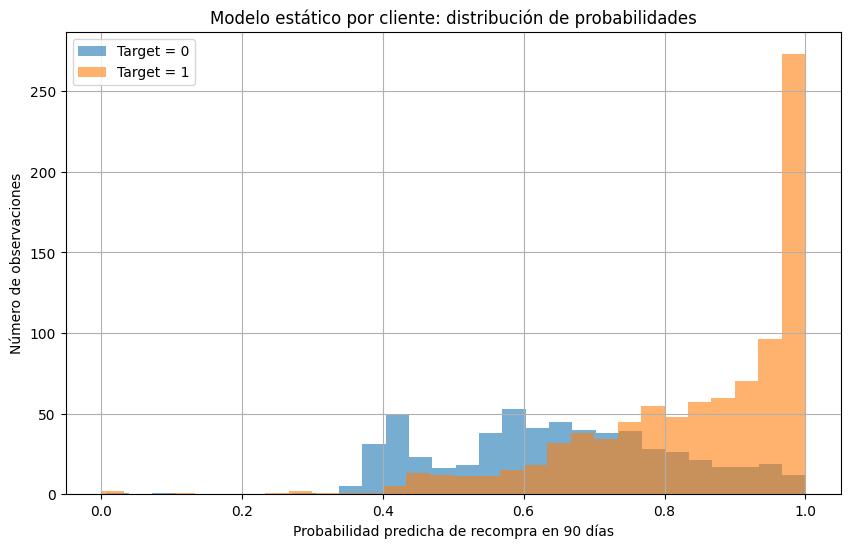


Tabla lift por decil:
   decile  n_obs  precision      lift
0       1    149   0.946309  1.553751
1       2    148   0.959459  1.575343
2       3    148   0.824324  1.353464
3       4    148   0.770270  1.264712
4       5    148   0.675676  1.109397
5       6    148   0.581081  0.954081
6       7    148   0.479730  0.787672
7       8    148   0.358108  0.587980
8       9    148   0.290541  0.477041
9      10    148   0.202703  0.332819


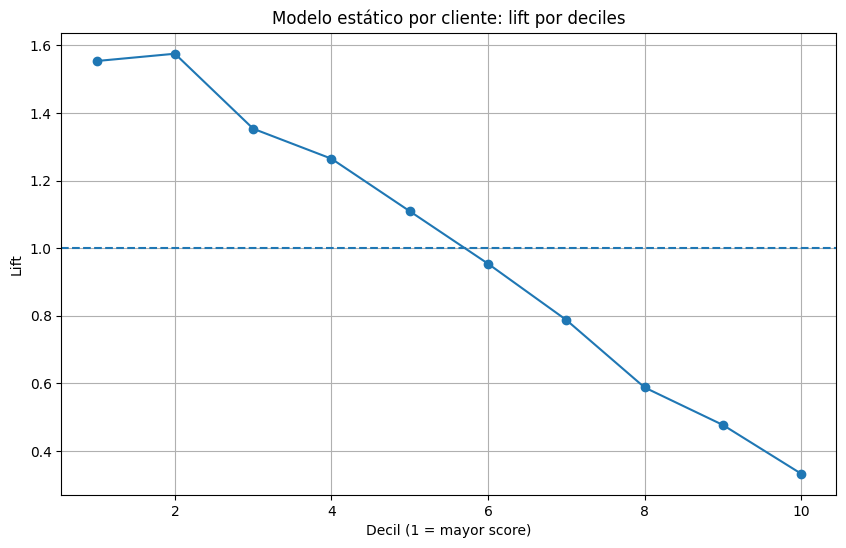

In [2]:

# MODELO ESTÁTICO POR CLIENTE: ¿RECOMPRA EN 90 DÍAS?

# %% =========================================
# 1) CARGA Y LIMPIEZA
# =========================================
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix


# Fechas
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

# Limpieza básica
df_clean = df[
    (df["Customer ID"].notnull()) &
    (df["Quantity"] > 0) &
    (df["Price"] > 0) &
    (df["InvoiceDate"].notnull())
].copy()

# Ingreso por línea
df_clean["total"] = df_clean["Quantity"] * df_clean["Price"]

print("Registros limpios:", len(df_clean))
print("Clientes únicos:", df_clean["Customer ID"].nunique())
print("Rango fechas:", df_clean["InvoiceDate"].min(), "→", df_clean["InvoiceDate"].max())


# %% =========================================
# 2) AGREGAR A NIVEL FACTURA
# =========================================
# Una fila por cliente-factura
df_inv = (
    df_clean.groupby(["Customer ID", "Invoice"], as_index=False)
    .agg(
        InvoiceDate=("InvoiceDate", "min"),
        total=("total", "sum"),
        Quantity=("Quantity", "sum"),
        Country=("Country", "first"),
        n_unique_products=("StockCode", "nunique")
    )
)

df_inv = df_inv.sort_values(["Customer ID", "InvoiceDate"]).reset_index(drop=True)

print("Facturas únicas:", len(df_inv))


# %% =========================================
# 3) CONSTRUIR DATASET ESTÁTICO A NIVEL CLIENTE
#    TARGET:
#    ¿compra en <= 90 días después de la fecha de observación?
# =========================================
HORIZON_DAYS = 90

# Fecha máxima del dataset
max_date = df_inv["InvoiceDate"].max()

# Fecha de corte global para construir features
# Tomamos el percentil 70 temporal para simular train/test temporal real
cutoff_date = df_inv["InvoiceDate"].quantile(0.7)

# Necesitamos 90 días observables después del cutoff
if cutoff_date + pd.Timedelta(days=HORIZON_DAYS) > max_date:
    cutoff_date = max_date - pd.Timedelta(days=HORIZON_DAYS)

print("Cutoff date:", cutoff_date)
print("Fin ventana target:", cutoff_date + pd.Timedelta(days=HORIZON_DAYS))

rows = []

for customer_id, g in df_inv.groupby("Customer ID", sort=False):
    g = g.sort_values("InvoiceDate").reset_index(drop=True)

    # Historial hasta cutoff_date
    g_hist = g[g["InvoiceDate"] <= cutoff_date].copy()

    # Futuro para target
    g_future = g[
        (g["InvoiceDate"] > cutoff_date) &
        (g["InvoiceDate"] <= cutoff_date + pd.Timedelta(days=HORIZON_DAYS))
    ].copy()

    # Si el cliente no tiene historial antes del cutoff, no podemos construir su estado
    if len(g_hist) == 0:
        continue

    dates = g_hist["InvoiceDate"].to_numpy(dtype="datetime64[ns]")
    totals = g_hist["total"].to_numpy(float)
    qtys = g_hist["Quantity"].to_numpy(float)
    nprod = g_hist["n_unique_products"].to_numpy(float)

    ctot = np.cumsum(totals)
    cqty = np.cumsum(qtys)
    cprod = np.cumsum(nprod)

    last_date = pd.Timestamp(dates[-1])
    first_date = pd.Timestamp(dates[0])

    # ---------- TARGET ----------
    target = int(len(g_future) > 0)

    # ---------- FEATURES DEL CLIENTE HASTA CUTOFF ----------
    if len(g_hist) >= 2:
        prev_date = pd.Timestamp(dates[-2])
        recency = (last_date - prev_date).days
    else:
        recency = 0

    customer_age = (last_date - first_date).days
    frequency = len(g_hist)
    monetary = ctot[-1]
    avg_ticket = monetary / frequency
    avg_products_per_invoice = cprod[-1] / frequency

    cantidad_total = df_inv.groupby("Customer ID")["Quantity"].sum()


    # Tiempo medio y std entre compras
    if len(g_hist) >= 2:
        diffs = np.diff(pd.to_datetime(dates).view("int64")) / (1e9 * 3600 * 24)
        avg_time_between = float(np.mean(diffs))
        std_time_between = float(np.std(diffs))
    else:
        avg_time_between = np.nan
        std_time_between = np.nan

    # ---------- VENTANAS RECIENTES ----------
    window_features = {}

    for w in [30, 60, 90, 180]:
        cutoff_w = np.datetime64(last_date - pd.Timedelta(days=w))
        left = np.searchsorted(dates, cutoff_w, side="left")

        freq_w = len(g_hist) - left
        spend_w = ctot[-1] - (ctot[left - 1] if left > 0 else 0.0)
        qty_w = cqty[-1] - (cqty[left - 1] if left > 0 else 0.0)

        window_features[f"freq_{w}"] = freq_w
        window_features[f"spend_{w}"] = spend_w
        window_features[f"qty_{w}"] = qty_w

    # Ratios recientes
    recent_ratio_30 = window_features["freq_30"] / frequency
    recent_ratio_90 = window_features["freq_90"] / frequency

    # Intensidades
    monetary_per_day = monetary / (customer_age + 1)
    freq_per_day = frequency / (customer_age + 1)

    rows.append({
        "Customer ID": customer_id,
        "snapshot_date": cutoff_date,
        "last_purchase_date": last_date,
        "country": g_hist["Country"].iloc[-1],
        "ultima_compra": (cutoff_date - last_date).days,

        "recency": recency,
        "customer_age": customer_age,
        "frequency": frequency,
        "monetary": monetary,
        "avg_ticket": avg_ticket,
        "avg_products_per_invoice": avg_products_per_invoice,
        "avg_time_between": avg_time_between,
        "std_time_between": std_time_between,
        "cantidad_total": cantidad_total.loc[customer_id],

        "freq_30": window_features["freq_30"],
        "freq_60": window_features["freq_60"],
        "freq_90": window_features["freq_90"],
        "freq_180": window_features["freq_180"],

        "spend_30": window_features["spend_30"],
        "spend_60": window_features["spend_60"],
        "spend_90": window_features["spend_90"],
        "spend_180": window_features["spend_180"],

        "qty_30": window_features["qty_30"],
        "qty_60": window_features["qty_60"],
        "qty_90": window_features["qty_90"],
        "qty_180": window_features["qty_180"],

        "recent_ratio_30": recent_ratio_30,
        "recent_ratio_90": recent_ratio_90,
        "monetary_per_day": monetary_per_day,
        "freq_per_day": freq_per_day,

        "has_repeat_purchase": int(frequency > 1),
        "target": target
    })

df_features = pd.DataFrame(rows)

print("Filas dataset estático:", len(df_features))
print("\nDistribución target:")
print(df_features["target"].value_counts())
print(df_features["target"].value_counts(normalize=True))


# %% =========================================
# 4) SPLIT TEMPORAL ESTÁTICO
# =========================================
# Para hacerlo temporal de verdad:
# entrenamos con clientes cuyo last_purchase_date sea más antigua
# y testeamos con clientes con last_purchase_date más reciente
split_date = df_features["last_purchase_date"].quantile(0.7)

train_idx = df_features["last_purchase_date"] <= split_date
test_idx = df_features["last_purchase_date"] > split_date

print("\nTrain clientes:", train_idx.sum())
print("Test clientes:", test_idx.sum())
print("Split date:", split_date)


# %% =========================================
# 5) PREPARACIÓN PARA MODELADO
# =========================================
num_features = [
    "recency",
    "ultima_compra",
    # "customer_age",
    "cantidad_total",
    "frequency",
    "monetary",
    "avg_ticket",
    # "avg_products_per_invoice",
    "avg_time_between",
    "std_time_between",
    # "freq_30",
    # "freq_60",
    "freq_90",
    # "freq_180",
    # "spend_30",
    # "spend_60",
    "spend_90",
    # "spend_180",
    # "qty_30",
    # "qty_60",
    "qty_90",
    # "qty_180",
    # "recent_ratio_30",
    # "recent_ratio_90",
    # "monetary_per_day",
    # "freq_per_day",
    "has_repeat_purchase"
]

cat_features = ["country"]

X = df_features[num_features + cat_features]
y = df_features["target"]

X_train = X.loc[train_idx].copy()
X_test = X.loc[test_idx].copy()
y_train = y.loc[train_idx].copy()
y_test = y.loc[test_idx].copy()


# %% =========================================
# 6) PIPELINE + MODELO
# =========================================
preprocess = ColumnTransformer([
    (
        "num",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]),
        num_features
    ),
    (
        "cat",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]),
        cat_features
    )
])

model = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

model.fit(X_train, y_train)


# %% =========================================
# 7) EVALUACIÓN
# =========================================
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)

auc = roc_auc_score(y_test, y_pred_proba)

print("\nROC-AUC:", auc)
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred))


# %% =========================================
# 8) PRECISION BASE, TOP 20% Y LIFT
# =========================================
df_eval = pd.DataFrame({
    "y_true": y_test.values,
    "y_score": y_pred_proba
}).sort_values("y_score", ascending=False)

top_n = int(len(df_eval) * 0.2)

precision_base = df_eval["y_true"].mean()
precision_top20 = df_eval.iloc[:top_n]["y_true"].mean()
lift = precision_top20 / precision_base

print("Precision base:", round(precision_base, 3))
print("Precision top 20%:", round(precision_top20, 3))
print("Lift:", round(lift, 2))


# %% =========================================
# 9) IMPORTANCIA DE VARIABLES
# =========================================
feature_names = model.named_steps["prep"].get_feature_names_out()
coefs = model.named_steps["clf"].coef_[0]

importance = (
    pd.Series(coefs, index=feature_names)
    .sort_values(key=np.abs, ascending=False)
)

print("\nTop 25 coeficientes por magnitud:")
print(importance.head(25))


# %% =========================================
# 10) HISTOGRAMA DE PROBABILIDADES
# =========================================
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(y_pred_proba[y_test == 0], bins=30, alpha=0.6, label="Target = 0")
plt.hist(y_pred_proba[y_test == 1], bins=30, alpha=0.6, label="Target = 1")
plt.xlabel("Probabilidad predicha de recompra en 90 días")
plt.ylabel("Número de observaciones")
plt.title("Modelo estático por cliente: distribución de probabilidades")
plt.legend()
plt.grid(True)
plt.show()


# %% =========================================
# 11) CURVA DE LIFT POR DECILES
# =========================================
df_lift = df_eval.copy()
df_lift["decile"] = pd.qcut(
    df_lift["y_score"].rank(method="first", ascending=False),
    10,
    labels=False
) + 1

lift_table = (
    df_lift.groupby("decile")
    .agg(
        n_obs=("y_true", "size"),
        precision=("y_true", "mean")
    )
    .reset_index()
)

lift_table["lift"] = lift_table["precision"] / precision_base

print("\nTabla lift por decil:")
print(lift_table)

plt.figure(figsize=(10, 6))
plt.plot(lift_table["decile"], lift_table["lift"], marker="o")
plt.axhline(1.0, linestyle="--")
plt.xlabel("Decil (1 = mayor score)")
plt.ylabel("Lift")
plt.title("Modelo estático por cliente: lift por deciles")
plt.grid(True)
plt.show()

## Graficos

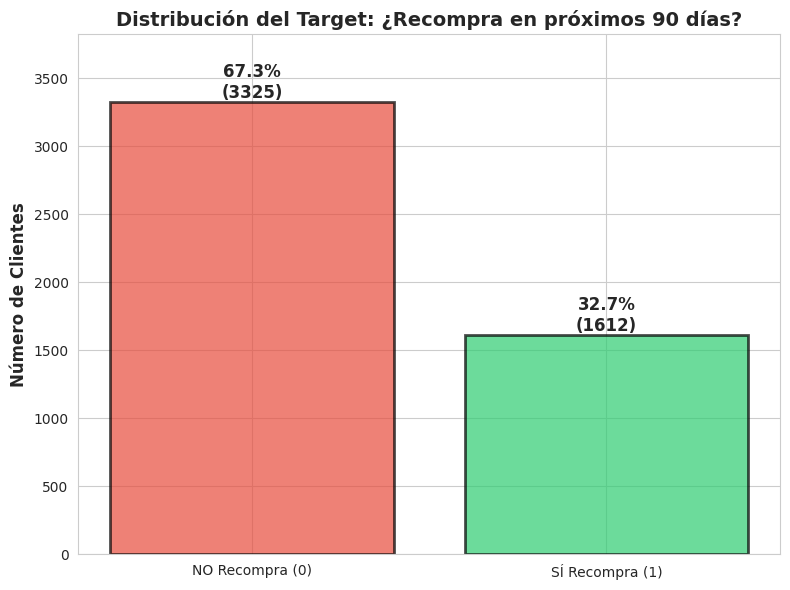


INSIGHT 1: DISTRIBUCIÓN DEL TARGET
Clientes que NO recompran (0): 3325 (67.3%)
Clientes que SÍ recompran (1): 1612 (32.7%)
Dataset DESBALANCEADO: usar class_weight='balanced' en el modelo


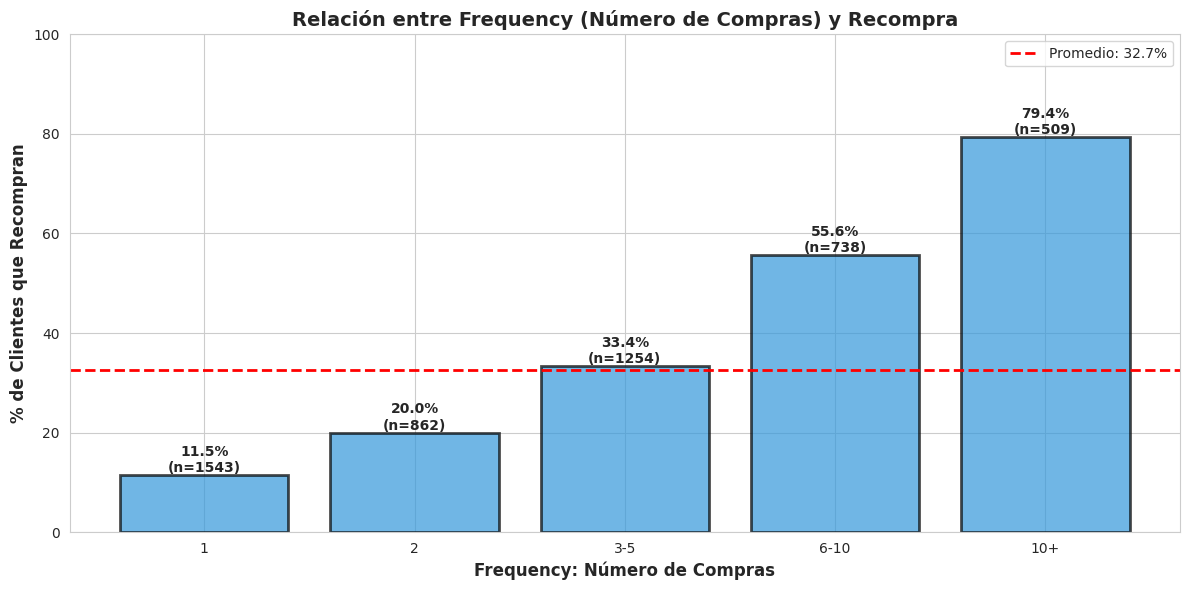


INSIGHT 2: FREQUENCY vs RECOMPRA
          sum  count  tasa_recompra
freq_bin                           
1         178   1543           11.5
2         172    862           20.0
3-5       419   1254           33.4
6-10      410    738           55.6
10+       404    509           79.4

Insight: Clientes con MÁS compras tienen MUCHA más probabilidad de recompra


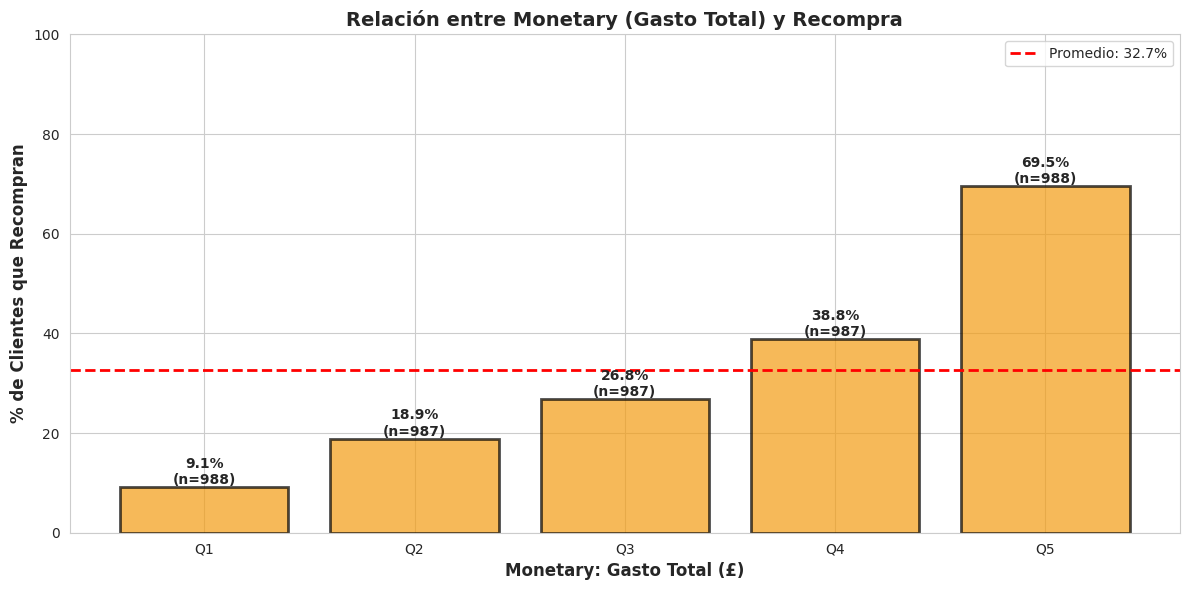


INSIGHT 3: MONETARY vs RECOMPRA
                       sum  count  tasa_recompra
monetary_bin                                    
(2.899, 260.034]        90    988            9.1
(260.034, 530.158]     187    987           18.9
(530.158, 1071.886]    265    987           26.8
(1071.886, 2446.502]   383    987           38.8
(2446.502, 385971.85]  687    988           69.5


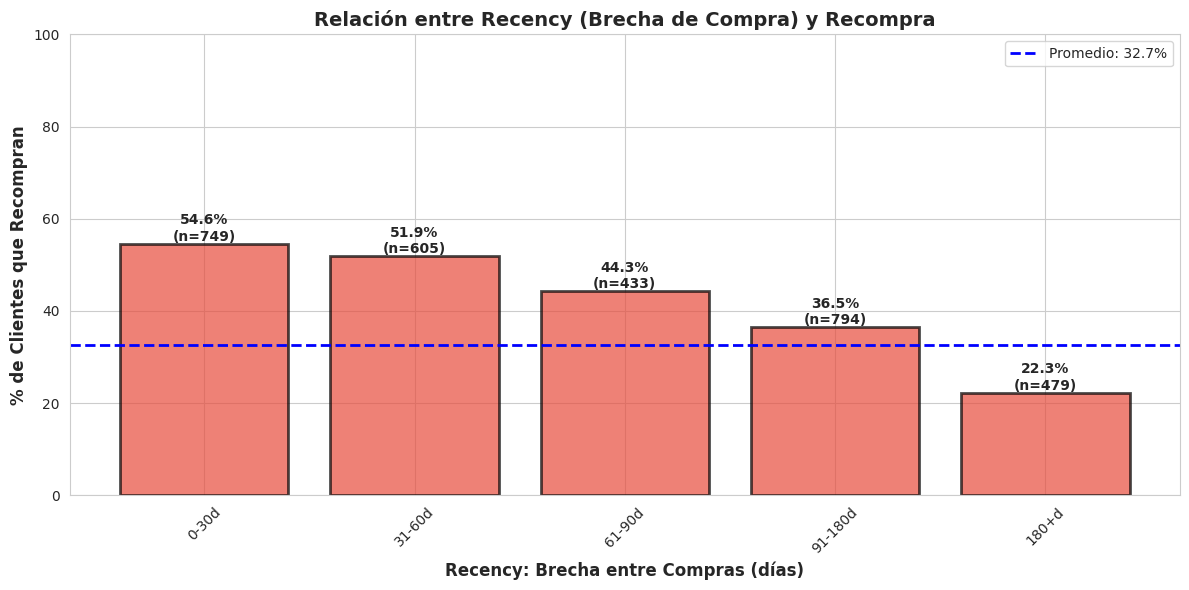


INSIGHT 4: RECENCY vs RECOMPRA
             sum  count  tasa_recompra
recency_bin                           
0-30d        409    749           54.6
31-60d       314    605           51.9
61-90d       192    433           44.3
91-180d      290    794           36.5
180+d        107    479           22.3

Insight: RECENCY ALTO = MÁS riesgo de churn. Clientes con brechas grandes no recompran


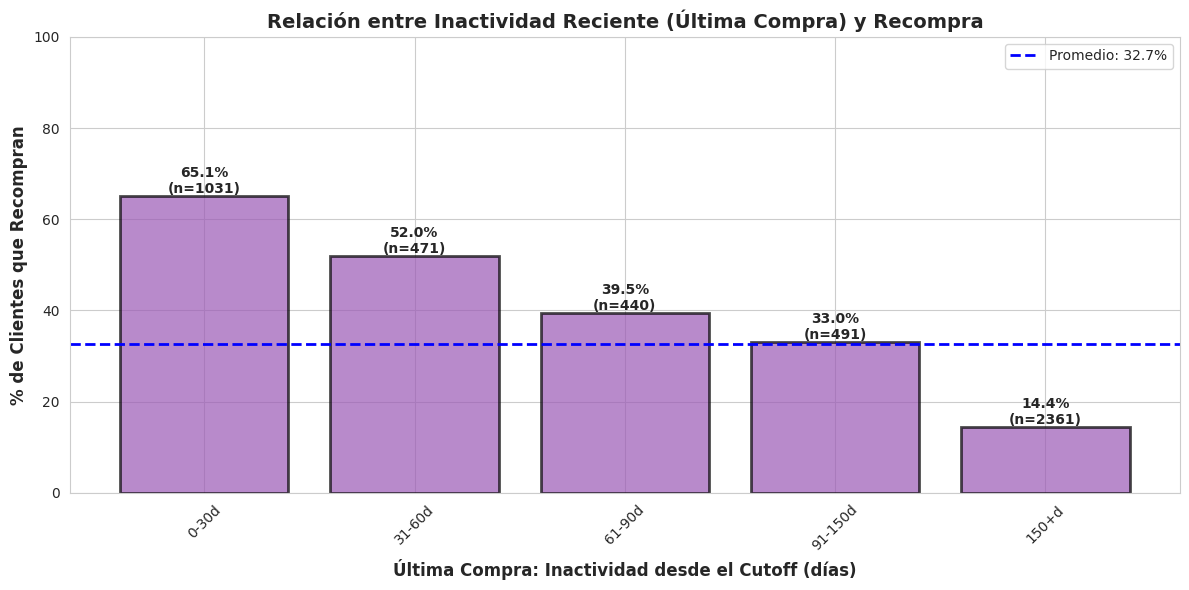


INSIGHT 5: INACTIVIDAD (última_compra) vs RECOMPRA
                 sum  count  tasa_recompra
inactividad_bin                           
0-30d            671   1031           65.1
31-60d           245    471           52.0
61-90d           174    440           39.5
91-150d          162    491           33.0
150+d            339   2361           14.4

Insight: Clientes inactivos >90 días tienen MUCHO menos probabilidad de recompra


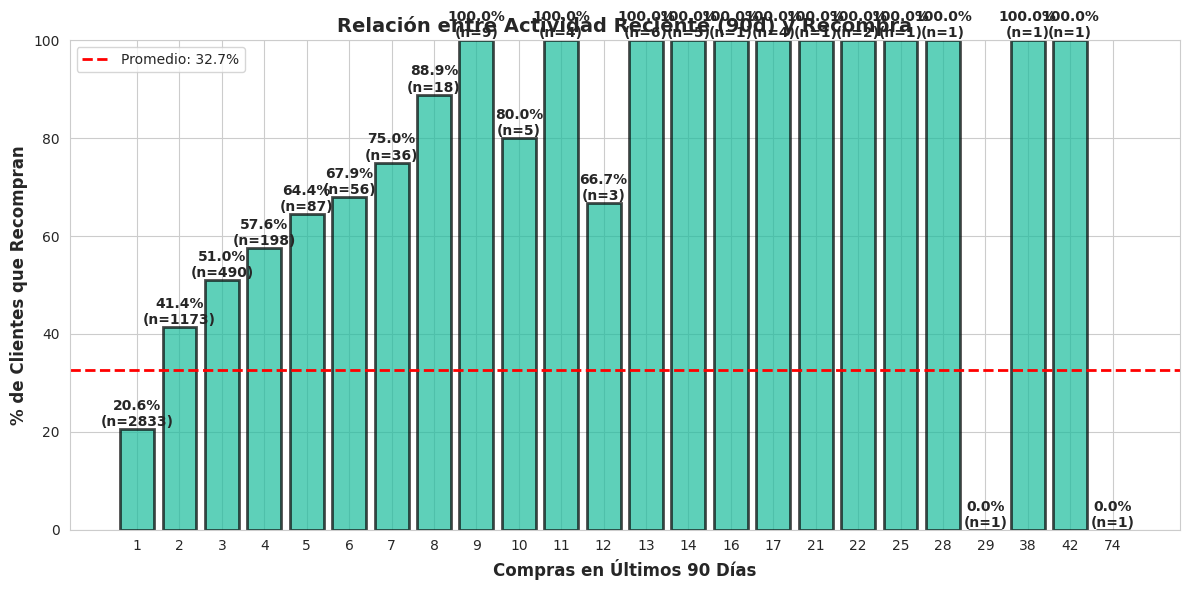


INSIGHT 6: ACTIVIDAD RECIENTE (freq_90) vs RECOMPRA
         sum  count  tasa_recompra
freq_90                           
1        583   2833           20.6
2        486   1173           41.4
3        250    490           51.0
4        114    198           57.6
5         56     87           64.4
6         38     56           67.9
7         27     36           75.0
8         16     18           88.9
9          9      9          100.0
10         4      5           80.0
11         4      4          100.0
12         2      3           66.7
13         6      6          100.0
14         5      5          100.0
16         1      1          100.0
17         4      4          100.0
21         1      1          100.0
22         2      2          100.0
25         1      1          100.0
28         1      1          100.0
29         0      1            0.0
38         1      1          100.0
42         1      1          100.0
74         0      1            0.0

Insight: Clientes activos en últimos

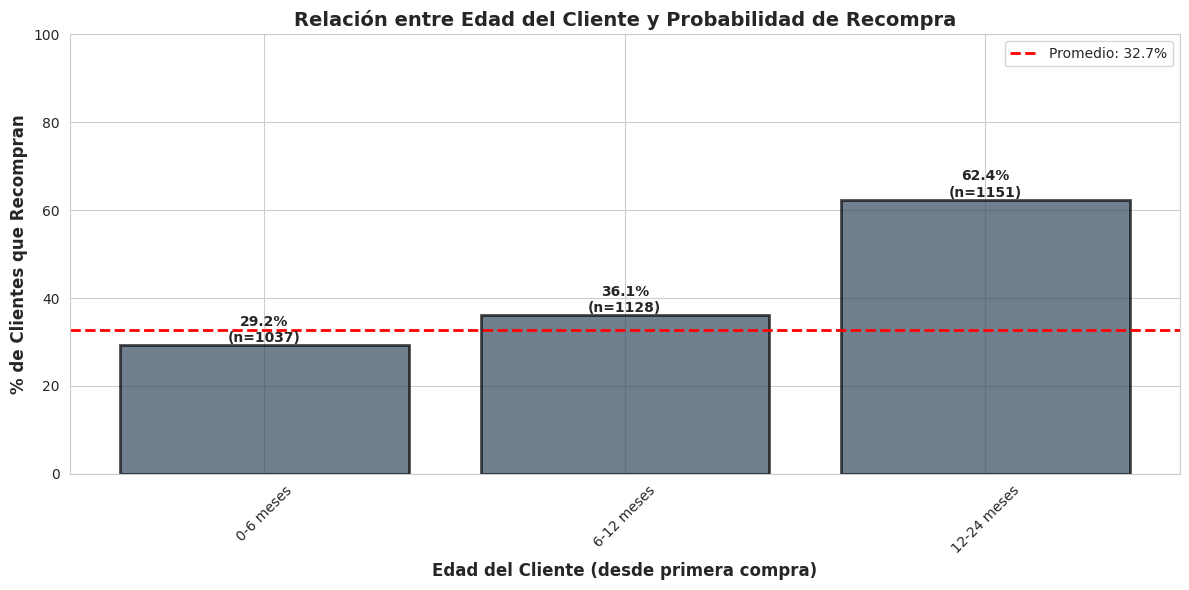


INSIGHT 7: CUSTOMER AGE vs RECOMPRA
             sum  count  tasa_recompra
age_bin                               
0-6 meses    303   1037           29.2
6-12 meses   407   1128           36.1
12-24 meses  718   1151           62.4

Insight: Clientes nuevos (0-6 meses) tienen menor probabilidad de recompra


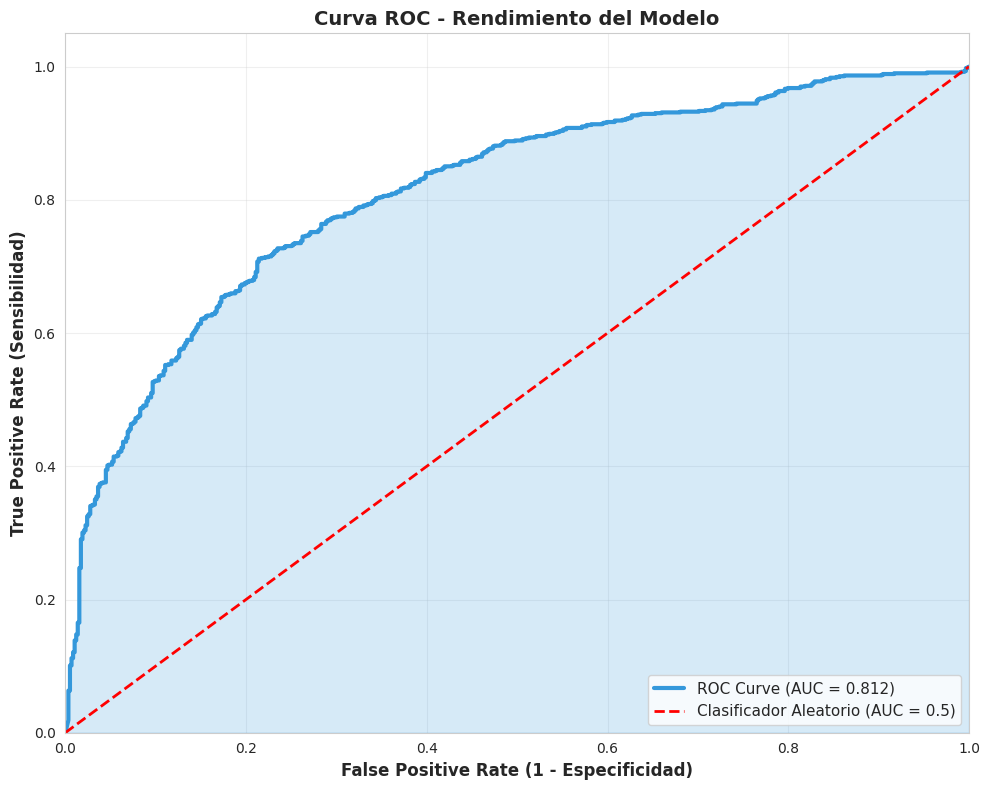


INSIGHT 8: CURVA ROC Y AUC
AUC-ROC: 0.8119
Interpretación: El modelo tiene un 81.2% de probabilidad de distinguir entre:
  - Un cliente que recompra
  - Un cliente que NO recompra

Valores AUC: 0.5=malo, 0.7=aceptable, 0.8=bueno, 0.9+=excelente
✓ AUC > 0.8: MODELO BUENO para usar en producción


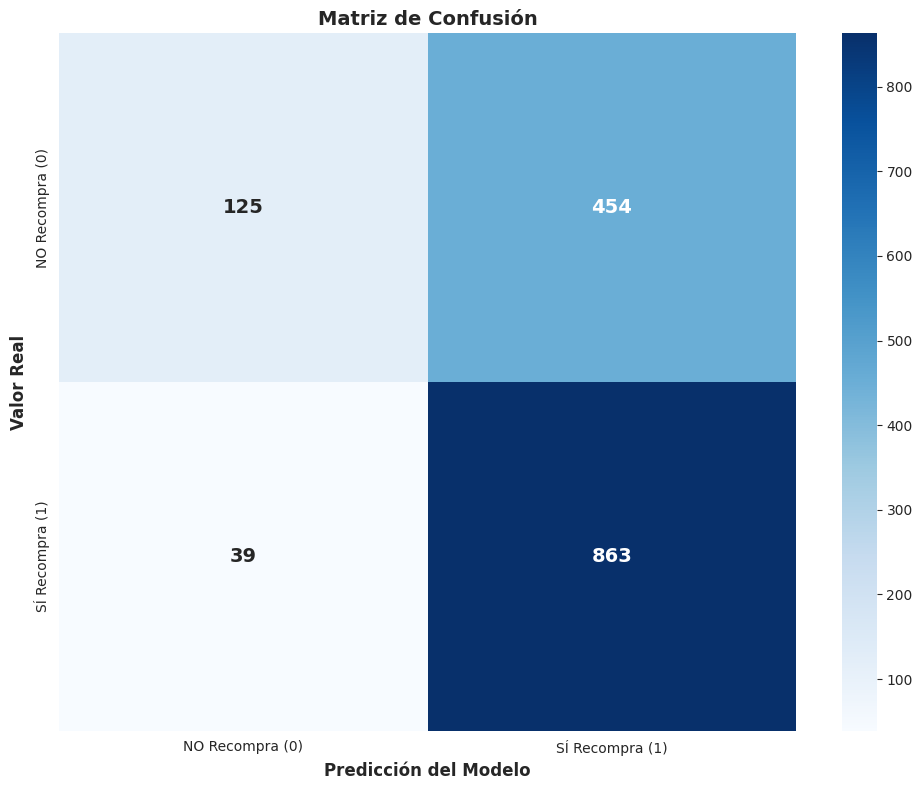


INSIGHT 9: MATRIZ DE CONFUSIÓN
Verdaderos Negativos (TN): 125 (predijo NO, era NO) ✓
Falsos Positivos (FP): 454 (predijo SÍ, era NO) ✗
Falsos Negativos (FN): 39 (predijo NO, era SÍ) ✗✗ PEOR
Verdaderos Positivos (TP): 863 (predijo SÍ, era SÍ) ✓

Métricas:
  Sensibilidad (TPR): 0.957 (¿cuántos que recompran detectamos?)
  Especificidad (TNR): 0.216 (¿cuántos que NO recompran detectamos?)
  Precisión: 0.655 (¿de los que predimos que compran, cuántos realmente lo hacen?)


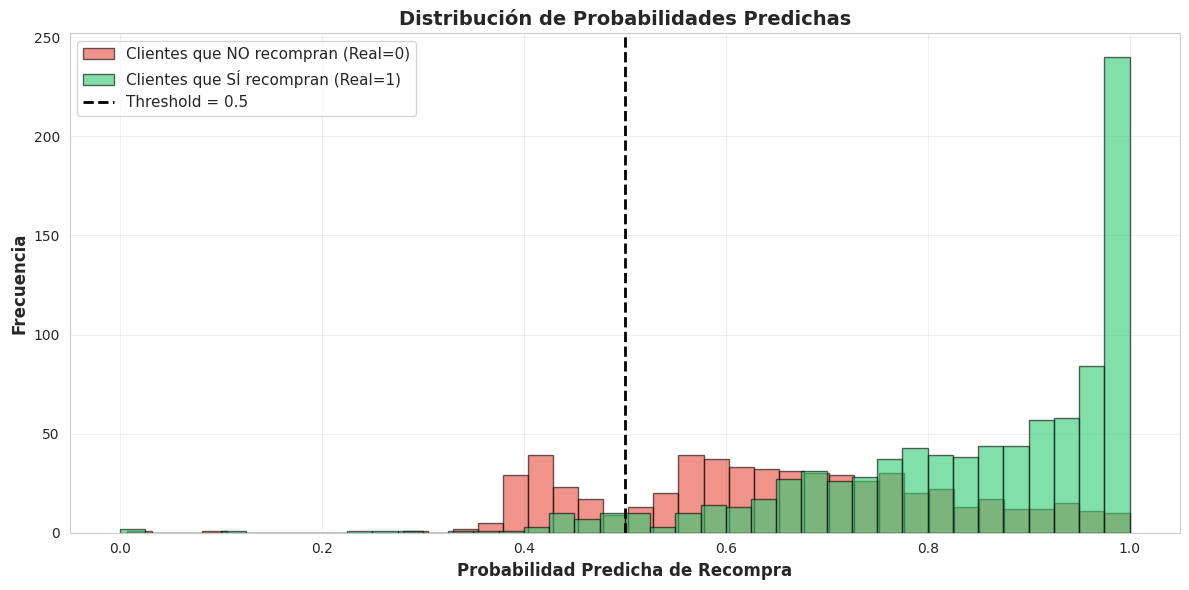


INSIGHT 10: DISTRIBUCIÓN DE PROBABILIDADES PREDICHAS
Probabilidad promedio para clientes que NO recompran: 0.648
Probabilidad promedio para clientes que SÍ recompran: 0.845

Insight: Hay buena separación entre las dos distribuciones → modelo diferencia bien


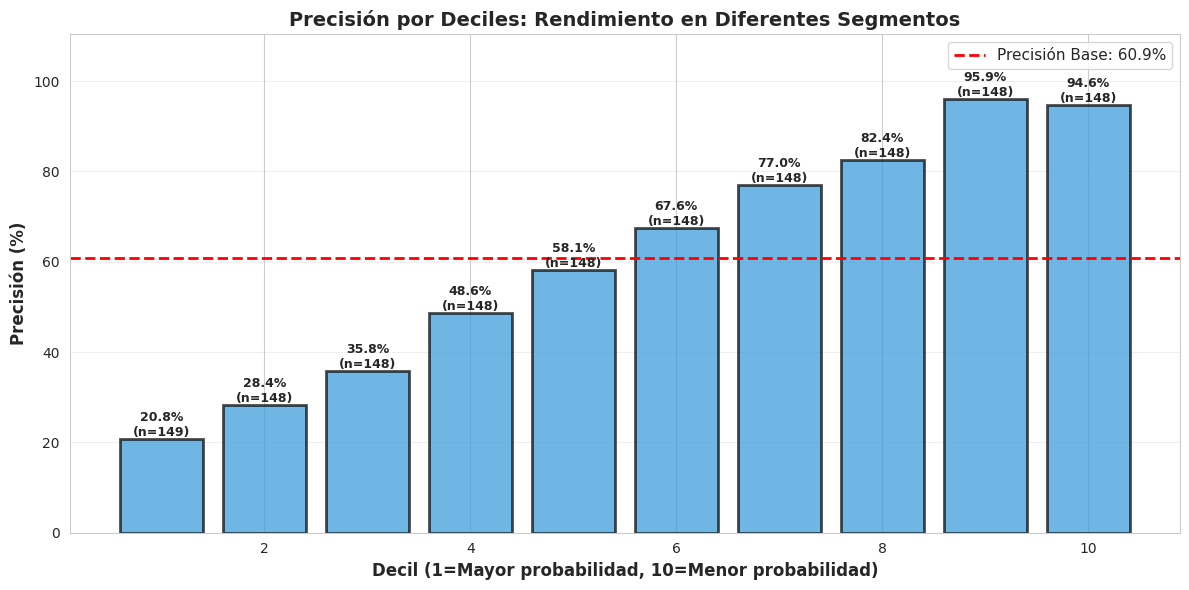


INSIGHT 11: PRECISIÓN POR DECILES
   decile  recompras  total_clientes  precision      lift
0       1         31             149  20.805369  0.341605
1       2         42             148  28.378378  0.465947
2       3         53             148  35.810811  0.587980
3       4         72             148  48.648649  0.798766
4       5         86             148  58.108108  0.954081
5       6        100             148  67.567568  1.109397
6       7        114             148  77.027027  1.264712
7       8        122             148  82.432432  1.353464
8       9        142             148  95.945946  1.575343
9      10        140             148  94.594595  1.553155

Insight: Si enfocas acciones en Decil 1 (top 10%), aciertas 20.8%
Lift en Decil 1: 0.34x (modelo es 0.34x mejor que random)

TODAS LAS GRÁFICAS GENERADAS
✓ 01_distribucion_target.png
✓ 02_frequency_vs_recompra.png
✓ 03_monetary_vs_recompra.png
✓ 04_recency_vs_recompra.png
✓ 05_inactividad_vs_recompra.png
✓ 06_freq_90_vs_reco

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

# Configurar estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

# ============================================================================
# ASUME QUE TIENES: df_static, y_test, y_pred_proba
# ============================================================================

# %% =========================================
# GRÁFICA 1: DISTRIBUCIÓN DEL TARGET
# =========================================
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

target_counts = df_features['target'].value_counts()
colors = ['#e74c3c', '#2ecc71']
labels = ['NO Recompra (0)', 'SÍ Recompra (1)']

bars = ax.bar(labels, [target_counts[0], target_counts[1]], color=colors, alpha=0.7, edgecolor='black', linewidth=2)

# Añadir porcentajes
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height/len(df_features)*100:.1f}%\n({int(height)})',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Número de Clientes', fontsize=12, fontweight='bold')
ax.set_title('Distribución del Target: ¿Recompra en próximos 90 días?', fontsize=14, fontweight='bold')
ax.set_ylim([0, max(target_counts) * 1.15])

plt.tight_layout()
plt.savefig('01_distribucion_target.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*70}")
print("INSIGHT 1: DISTRIBUCIÓN DEL TARGET")
print(f"{'='*70}")
print(f"Clientes que NO recompran (0): {target_counts[0]} ({target_counts[0]/len(df_features)*100:.1f}%)")
print(f"Clientes que SÍ recompran (1): {target_counts[1]} ({target_counts[1]/len(df_features)*100:.1f}%)")
print(f"Dataset DESBALANCEADO: usar class_weight='balanced' en el modelo")

# %% =========================================
# GRÁFICA 2: FREQUENCY vs RECOMPRA
# =========================================
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Crear bins de frequency
df_features['freq_bin'] = pd.cut(df_features['frequency'], bins=[0, 1, 2, 5, 10, 50], 
                                labels=['1', '2', '3-5', '6-10', '10+'])

recompra_by_freq = df_features.groupby('freq_bin')['target'].agg(['sum', 'count'])
recompra_by_freq['tasa_recompra'] = (recompra_by_freq['sum'] / recompra_by_freq['count'] * 100).round(1)

x = range(len(recompra_by_freq))
bars = ax.bar(x, recompra_by_freq['tasa_recompra'], color='#3498db', alpha=0.7, edgecolor='black', linewidth=2)

# Añadir percentajes y conteos
for i, (bar, count) in enumerate(zip(bars, recompra_by_freq['count'])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%\n(n={int(count)})',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Frequency: Número de Compras', fontsize=12, fontweight='bold')
ax.set_ylabel('% de Clientes que Recompran', fontsize=12, fontweight='bold')
ax.set_title('Relación entre Frequency (Número de Compras) y Recompra', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(recompra_by_freq.index)
ax.set_ylim([0, 100])

# Añadir línea de referencia (promedio)
avg_recompra = df_features['target'].mean() * 100
ax.axhline(y=avg_recompra, color='red', linestyle='--', linewidth=2, label=f'Promedio: {avg_recompra:.1f}%')
ax.legend()

plt.tight_layout()
plt.savefig('02_frequency_vs_recompra.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*70}")
print("INSIGHT 2: FREQUENCY vs RECOMPRA")
print(f"{'='*70}")
print(recompra_by_freq)
print(f"\nInsight: Clientes con MÁS compras tienen MUCHA más probabilidad de recompra")

# %% =========================================
# GRÁFICA 3: MONETARY (Gasto) vs RECOMPRA
# =========================================
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Crear bins de monetary
df_features['monetary_bin'] = pd.qcut(df_features['monetary'], q=5, duplicates='drop')

recompra_by_monetary = df_features.groupby('monetary_bin', observed=True)['target'].agg(['sum', 'count'])
recompra_by_monetary['tasa_recompra'] = (recompra_by_monetary['sum'] / recompra_by_monetary['count'] * 100).round(1)

x = range(len(recompra_by_monetary))
bars = ax.bar(x, recompra_by_monetary['tasa_recompra'], color='#f39c12', alpha=0.7, edgecolor='black', linewidth=2)

for i, (bar, count) in enumerate(zip(bars, recompra_by_monetary['count'])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%\n(n={int(count)})',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Monetary: Gasto Total (£)', fontsize=12, fontweight='bold')
ax.set_ylabel('% de Clientes que Recompran', fontsize=12, fontweight='bold')
ax.set_title('Relación entre Monetary (Gasto Total) y Recompra', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'Q{i+1}' for i in range(len(recompra_by_monetary))], rotation=0)
ax.set_ylim([0, 100])
ax.axhline(y=avg_recompra, color='red', linestyle='--', linewidth=2, label=f'Promedio: {avg_recompra:.1f}%')
ax.legend()

plt.tight_layout()
plt.savefig('03_monetary_vs_recompra.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*70}")
print("INSIGHT 3: MONETARY vs RECOMPRA")
print(f"{'='*70}")
print(recompra_by_monetary)

# %% =========================================
# GRÁFICA 4: RECENCY vs RECOMPRA
# =========================================
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Crear bins de recency
df_features['recency_bin'] = pd.cut(df_features['recency'], bins=[0, 30, 60, 90, 180, 1000],
                                   labels=['0-30d', '31-60d', '61-90d', '91-180d', '180+d'])

recompra_by_recency = df_features.groupby('recency_bin')['target'].agg(['sum', 'count'])
recompra_by_recency['tasa_recompra'] = (recompra_by_recency['sum'] / recompra_by_recency['count'] * 100).round(1)

x = range(len(recompra_by_recency))
bars = ax.bar(x, recompra_by_recency['tasa_recompra'], color='#e74c3c', alpha=0.7, edgecolor='black', linewidth=2)

for i, (bar, count) in enumerate(zip(bars, recompra_by_recency['count'])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%\n(n={int(count)})',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Recency: Brecha entre Compras (días)', fontsize=12, fontweight='bold')
ax.set_ylabel('% de Clientes que Recompran', fontsize=12, fontweight='bold')
ax.set_title('Relación entre Recency (Brecha de Compra) y Recompra', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(recompra_by_recency.index, rotation=45)
ax.set_ylim([0, 100])
ax.axhline(y=avg_recompra, color='blue', linestyle='--', linewidth=2, label=f'Promedio: {avg_recompra:.1f}%')
ax.legend()

plt.tight_layout()
plt.savefig('04_recency_vs_recompra.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*70}")
print("INSIGHT 4: RECENCY vs RECOMPRA")
print(f"{'='*70}")
print(recompra_by_recency)
print(f"\nInsight: RECENCY ALTO = MÁS riesgo de churn. Clientes con brechas grandes no recompran")

# %% =========================================
# GRÁFICA 5: ULTIMA COMPRA vs RECOMPRA (INACTIVIDAD)
# =========================================
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Crear bins de ultima_compra (inactividad respecto al cutoff)
df_features['inactividad_bin'] = pd.cut(df_features['ultima_compra'], 
                                       bins=[0, 30, 60, 90, 150, 500],
                                       labels=['0-30d', '31-60d', '61-90d', '91-150d', '150+d'])

recompra_by_inactividad = df_features.groupby('inactividad_bin', observed=True)['target'].agg(['sum', 'count'])
recompra_by_inactividad['tasa_recompra'] = (recompra_by_inactividad['sum'] / recompra_by_inactividad['count'] * 100).round(1)

x = range(len(recompra_by_inactividad))
bars = ax.bar(x, recompra_by_inactividad['tasa_recompra'], color='#9b59b6', alpha=0.7, edgecolor='black', linewidth=2)

for i, (bar, count) in enumerate(zip(bars, recompra_by_inactividad['count'])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%\n(n={int(count)})',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Última Compra: Inactividad desde el Cutoff (días)', fontsize=12, fontweight='bold')
ax.set_ylabel('% de Clientes que Recompran', fontsize=12, fontweight='bold')
ax.set_title('Relación entre Inactividad Reciente (Última Compra) y Recompra', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(recompra_by_inactividad.index, rotation=45)
ax.set_ylim([0, 100])
ax.axhline(y=avg_recompra, color='blue', linestyle='--', linewidth=2, label=f'Promedio: {avg_recompra:.1f}%')
ax.legend()

plt.tight_layout()
plt.savefig('05_inactividad_vs_recompra.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*70}")
print("INSIGHT 5: INACTIVIDAD (última_compra) vs RECOMPRA")
print(f"{'='*70}")
print(recompra_by_inactividad)
print(f"\nInsight: Clientes inactivos >90 días tienen MUCHO menos probabilidad de recompra")

# %% =========================================
# GRÁFICA 6: ACTIVIDAD RECIENTE (freq_90) vs RECOMPRA
# =========================================
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# freq_90 es número de compras en últimos 90 días
recompra_by_freq90 = df_features.groupby('freq_90')['target'].agg(['sum', 'count'])
recompra_by_freq90['tasa_recompra'] = (recompra_by_freq90['sum'] / recompra_by_freq90['count'] * 100).round(1)

x = range(len(recompra_by_freq90))
bars = ax.bar(x, recompra_by_freq90['tasa_recompra'], color='#1abc9c', alpha=0.7, edgecolor='black', linewidth=2)

for i, (bar, count) in enumerate(zip(bars, recompra_by_freq90['count'])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%\n(n={int(count)})',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Compras en Últimos 90 Días', fontsize=12, fontweight='bold')
ax.set_ylabel('% de Clientes que Recompran', fontsize=12, fontweight='bold')
ax.set_title('Relación entre Actividad Reciente (90d) y Recompra', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([int(i) for i in recompra_by_freq90.index])
ax.set_ylim([0, 100])
ax.axhline(y=avg_recompra, color='red', linestyle='--', linewidth=2, label=f'Promedio: {avg_recompra:.1f}%')
ax.legend()

plt.tight_layout()
plt.savefig('06_freq_90_vs_recompra.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*70}")
print("INSIGHT 6: ACTIVIDAD RECIENTE (freq_90) vs RECOMPRA")
print(f"{'='*70}")
print(recompra_by_freq90)
print(f"\nInsight: Clientes activos en últimos 90d tienen MUCHA mayor probabilidad de recompra")

# %% =========================================
# GRÁFICA 7: CUSTOMER AGE vs RECOMPRA
# =========================================
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

df_features['age_bin'] = pd.cut(df_features['customer_age'], 
                               bins=[0, 180, 365, 730, 1000],
                               labels=['0-6 meses', '6-12 meses', '12-24 meses', '24+ meses'])

recompra_by_age = df_features.groupby('age_bin', observed=True)['target'].agg(['sum', 'count'])
recompra_by_age['tasa_recompra'] = (recompra_by_age['sum'] / recompra_by_age['count'] * 100).round(1)

x = range(len(recompra_by_age))
bars = ax.bar(x, recompra_by_age['tasa_recompra'], color='#34495e', alpha=0.7, edgecolor='black', linewidth=2)

for i, (bar, count) in enumerate(zip(bars, recompra_by_age['count'])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%\n(n={int(count)})',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Edad del Cliente (desde primera compra)', fontsize=12, fontweight='bold')
ax.set_ylabel('% de Clientes que Recompran', fontsize=12, fontweight='bold')
ax.set_title('Relación entre Edad del Cliente y Probabilidad de Recompra', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(recompra_by_age.index, rotation=45)
ax.set_ylim([0, 100])
ax.axhline(y=avg_recompra, color='red', linestyle='--', linewidth=2, label=f'Promedio: {avg_recompra:.1f}%')
ax.legend()

plt.tight_layout()
plt.savefig('07_customer_age_vs_recompra.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*70}")
print("INSIGHT 7: CUSTOMER AGE vs RECOMPRA")
print(f"{'='*70}")
print(recompra_by_age)
print(f"\nInsight: Clientes nuevos (0-6 meses) tienen menor probabilidad de recompra")

# %% =========================================
# GRÁFICA 8: CURVA ROC Y AUC
# =========================================
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

ax.plot(fpr, tpr, color='#3498db', lw=3, label=f'ROC Curve (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Clasificador Aleatorio (AUC = 0.5)')

ax.fill_between(fpr, tpr, alpha=0.2, color='#3498db')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (1 - Especificidad)', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate (Sensibilidad)', fontsize=12, fontweight='bold')
ax.set_title('Curva ROC - Rendimiento del Modelo', fontsize=14, fontweight='bold')
ax.legend(loc="lower right", fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('08_curva_roc.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*70}")
print("INSIGHT 8: CURVA ROC Y AUC")
print(f"{'='*70}")
print(f"AUC-ROC: {roc_auc:.4f}")
print(f"Interpretación: El modelo tiene un {roc_auc*100:.1f}% de probabilidad de distinguir entre:")
print(f"  - Un cliente que recompra")
print(f"  - Un cliente que NO recompra")
print(f"\nValores AUC: 0.5=malo, 0.7=aceptable, 0.8=bueno, 0.9+=excelente")
if roc_auc > 0.8:
    print(f"✓ AUC > 0.8: MODELO BUENO para usar en producción")

# %% =========================================
# GRÁFICA 9: MATRIZ DE CONFUSIÓN
# =========================================
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

y_pred = (y_pred_proba >= 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)

# Normalizar para porcentajes
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, ax=ax,
            xticklabels=['NO Recompra (0)', 'SÍ Recompra (1)'],
            yticklabels=['NO Recompra (0)', 'SÍ Recompra (1)'],
            annot_kws={'size': 14, 'weight': 'bold'})

ax.set_xlabel('Predicción del Modelo', fontsize=12, fontweight='bold')
ax.set_ylabel('Valor Real', fontsize=12, fontweight='bold')
ax.set_title('Matriz de Confusión', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('09_matriz_confusion.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*70}")
print("INSIGHT 9: MATRIZ DE CONFUSIÓN")
print(f"{'='*70}")
print(f"Verdaderos Negativos (TN): {cm[0,0]} (predijo NO, era NO) ✓")
print(f"Falsos Positivos (FP): {cm[0,1]} (predijo SÍ, era NO) ✗")
print(f"Falsos Negativos (FN): {cm[1,0]} (predijo NO, era SÍ) ✗✗ PEOR")
print(f"Verdaderos Positivos (TP): {cm[1,1]} (predijo SÍ, era SÍ) ✓")

tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
precision = tp / (tp + fp)

print(f"\nMétricas:")
print(f"  Sensibilidad (TPR): {sensitivity:.3f} (¿cuántos que recompran detectamos?)")
print(f"  Especificidad (TNR): {specificity:.3f} (¿cuántos que NO recompran detectamos?)")
print(f"  Precisión: {precision:.3f} (¿de los que predimos que compran, cuántos realmente lo hacen?)")

# %% =========================================
# GRÁFICA 10: DISTRIBUCIÓN DE PROBABILIDADES PREDICHAS
# =========================================
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

ax.hist(y_pred_proba[y_test == 0], bins=40, alpha=0.6, label='Clientes que NO recompran (Real=0)', 
        color='#e74c3c', edgecolor='black')
ax.hist(y_pred_proba[y_test == 1], bins=40, alpha=0.6, label='Clientes que SÍ recompran (Real=1)', 
        color='#2ecc71', edgecolor='black')

ax.axvline(0.5, color='black', linestyle='--', linewidth=2, label='Threshold = 0.5')
ax.set_xlabel('Probabilidad Predicha de Recompra', fontsize=12, fontweight='bold')
ax.set_ylabel('Frecuencia', fontsize=12, fontweight='bold')
ax.set_title('Distribución de Probabilidades Predichas', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('10_distribucion_probabilidades.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*70}")
print("INSIGHT 10: DISTRIBUCIÓN DE PROBABILIDADES PREDICHAS")
print(f"{'='*70}")
print(f"Probabilidad promedio para clientes que NO recompran: {y_pred_proba[y_test == 0].mean():.3f}")
print(f"Probabilidad promedio para clientes que SÍ recompran: {y_pred_proba[y_test == 1].mean():.3f}")
print(f"\nInsight: Hay buena separación entre las dos distribuciones → modelo diferencia bien")

# %% =========================================
# GRÁFICA 11: PRECISION POR DECILES
# =========================================
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

df_eval = pd.DataFrame({
    'y_true': y_test.values,
    'y_score': y_pred_proba
}).sort_values('y_score', ascending=False).reset_index(drop=True)

# Crear deciles
df_eval['decile'] = pd.qcut(df_eval['y_score'].rank(method='first'), 10, labels=False, duplicates='drop') + 1

decile_stats = df_eval.groupby('decile').agg({
    'y_true': ['sum', 'count', 'mean']
}).reset_index()

decile_stats.columns = ['decile', 'recompras', 'total_clientes', 'precision']
decile_stats['precision'] = decile_stats['precision'] * 100

base_precision = y_test.mean() * 100
decile_stats['lift'] = decile_stats['precision'] / base_precision

bars = ax.bar(decile_stats['decile'], decile_stats['precision'], color='#3498db', alpha=0.7, edgecolor='black', linewidth=2)

for i, (bar, count) in enumerate(zip(bars, decile_stats['total_clientes'])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%\n(n={int(count)})',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.axhline(y=base_precision, color='red', linestyle='--', linewidth=2, label=f'Precisión Base: {base_precision:.1f}%')

ax.set_xlabel('Decil (1=Mayor probabilidad, 10=Menor probabilidad)', fontsize=12, fontweight='bold')
ax.set_ylabel('Precisión (%)', fontsize=12, fontweight='bold')
ax.set_title('Precisión por Deciles: Rendimiento en Diferentes Segmentos', fontsize=14, fontweight='bold')
ax.set_ylim([0, max(decile_stats['precision']) * 1.15])
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('11_precision_por_deciles.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*70}")
print("INSIGHT 11: PRECISIÓN POR DECILES")
print(f"{'='*70}")
print(decile_stats)
print(f"\nInsight: Si enfocas acciones en Decil 1 (top 10%), aciertas {decile_stats.iloc[0]['precision']:.1f}%")
print(f"Lift en Decil 1: {decile_stats.iloc[0]['lift']:.2f}x (modelo es {decile_stats.iloc[0]['lift']:.2f}x mejor que random)")

# %% =========================================
# GRÁFICA 12: TOP VARIABLES IMPORTANTES
# =========================================
# ASUME QUE TIENES ACCESO A LOS COEFICIENTES DEL MODELO
# Descomenta si tienes el modelo entrenado

"""
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

feature_names = model.named_steps['prep'].get_feature_names_out()
coefs = model.named_steps['clf'].coef_[0]

importance = pd.Series(coefs, index=feature_names).sort_values(key=np.abs, ascending=False).head(15)

colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in importance.values]

bars = ax.barh(range(len(importance)), importance.values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)

ax.set_yticks(range(len(importance)))
ax.set_yticklabels(importance.index, fontsize=11)
ax.set_xlabel('Coeficiente (Impacto en Probabilidad de Recompra)', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Variables Más Importantes del Modelo', fontsize=14, fontweight='bold')
ax.axvline(0, color='black', linestyle='-', linewidth=1)
ax.grid(True, alpha=0.3, axis='x')

for i, (bar, val) in enumerate(zip(bars, importance.values)):
    x_pos = val + (0.05 if val > 0 else -0.05)
    ax.text(x_pos, bar.get_y() + bar.get_height()/2., f'{val:.3f}',
            ha='left' if val > 0 else 'right', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('12_variables_importantes.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*70}")
print("INSIGHT 12: VARIABLES MÁS IMPORTANTES")
print(f"{'='*70}")
print(importance)
print(f"\nVerdes (+): Variables que AUMENTAN probabilidad de recompra")
print(f"Rojas (-): Variables que DISMINUYEN probabilidad de recompra")
"""

print(f"\n{'='*70}")
print("TODAS LAS GRÁFICAS GENERADAS")
print(f"{'='*70}")
print("✓ 01_distribucion_target.png")
print("✓ 02_frequency_vs_recompra.png")
print("✓ 03_monetary_vs_recompra.png")
print("✓ 04_recency_vs_recompra.png")
print("✓ 05_inactividad_vs_recompra.png")
print("✓ 06_freq_90_vs_recompra.png")
print("✓ 07_customer_age_vs_recompra.png")
print("✓ 08_curva_roc.png")
print("✓ 09_matriz_confusion.png")
print("✓ 10_distribucion_probabilidades.png")
print("✓ 11_precision_por_deciles.png")
print("✓ 12_variables_importantes.png (descomenta si tienes el modelo)")



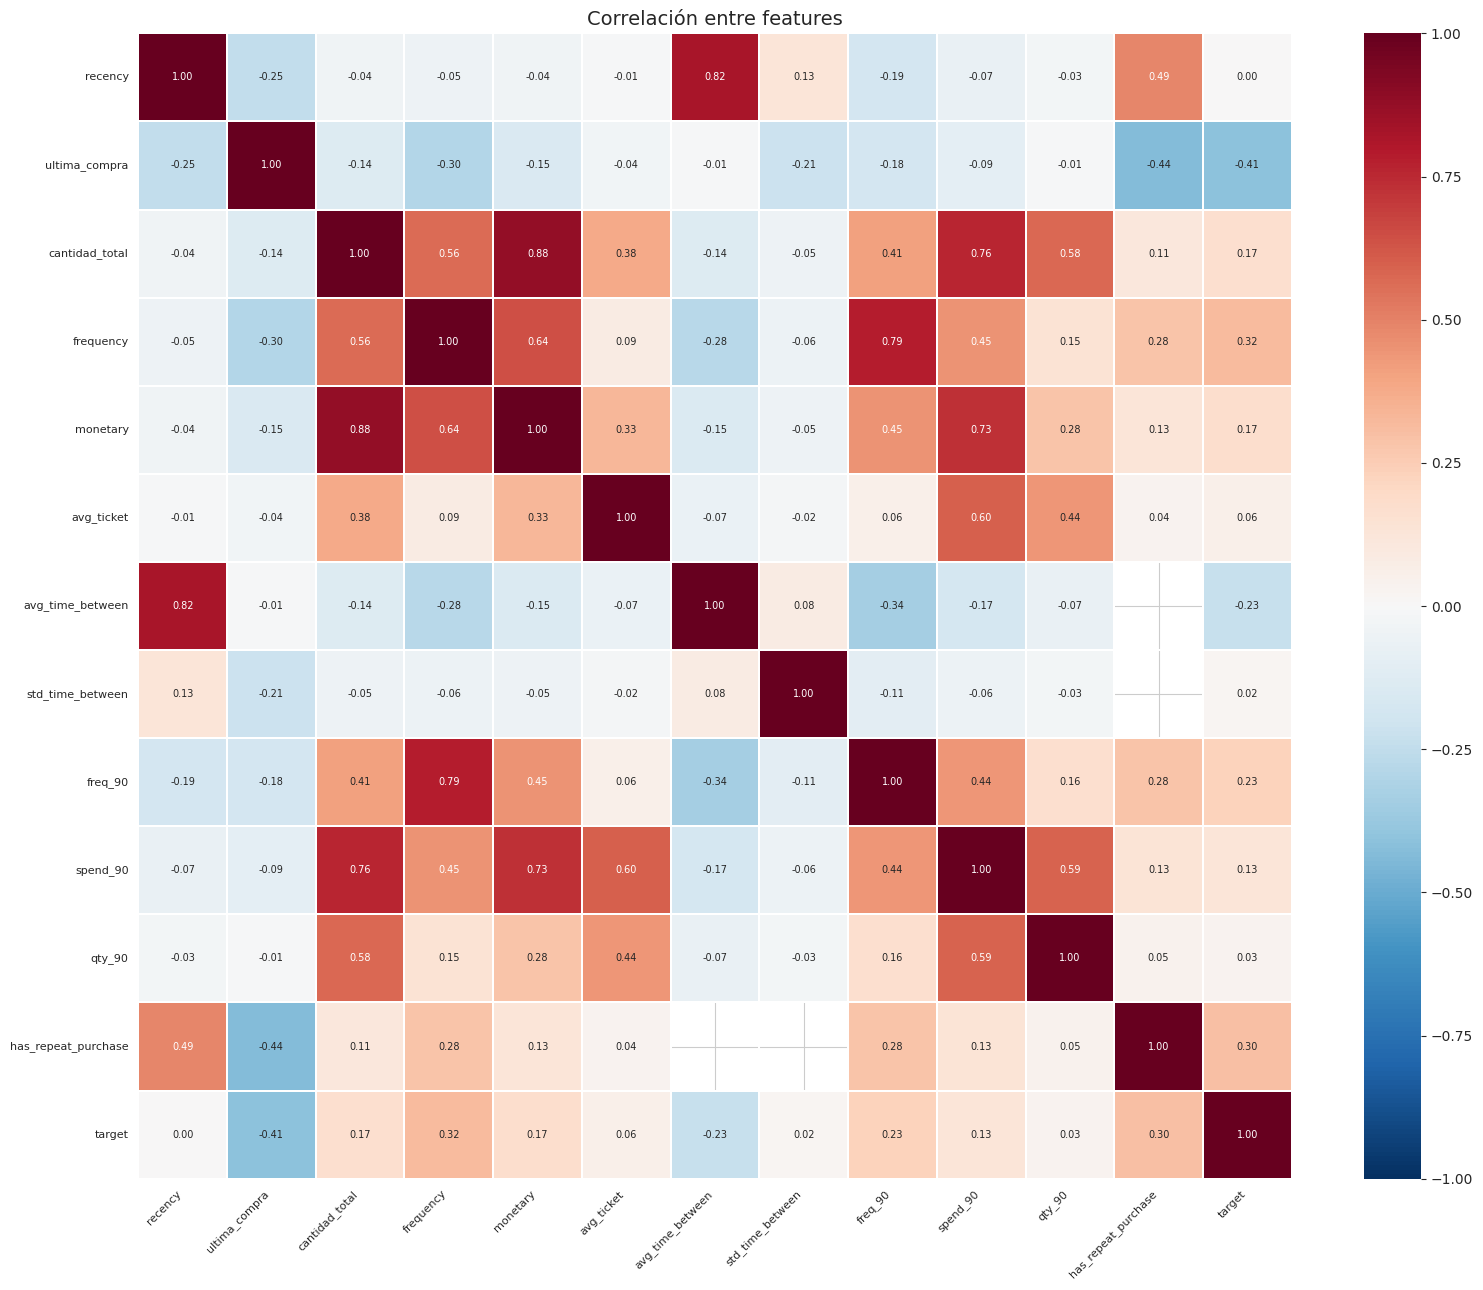

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionamos solo las numéricas + target
cols_plot = num_features + ["target"]
corr = df_features[cols_plot].corr()

# Mapa de correlaciones
plt.figure(figsize=(16, 13))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
    annot_kws={"size": 7}
)
plt.title("Correlación entre features", fontsize=14)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()